# TASK 2 - Umemployment Analysis

## Problem Statement
**Unemployment is measured by the unemployment rate, which is the percentage of unemployed people in the total labor force. The objective of this project is to analyze unemployment trends, especially during the COVID-19 period, and extract meaningful insights using data analysis and visualization techniques.**

**STEPS**
- Load dataset
- Clean and preprocess data
- Analyze trends over time
- Perform state-wise and region-wise analysis
- Study impact of COVID-19
- Visualize results

## Import Libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Dataset

In [12]:
df = pd.read_csv("UnemploymentIndia.csv")
df.columns = ['States', 'Date', 'Frequency', 'Estimated Unemployment Rate',
              'Estimated Employed', 'Estimated Labour Participation Rate', 'Region']
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

## Data Exploration

In [13]:
print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

First 5 rows:
           States       Date Frequency  Estimated Unemployment Rate  \
0  Andhra Pradesh 2019-05-31   Monthly                         3.65   
1  Andhra Pradesh 2019-06-30   Monthly                         3.05   
2  Andhra Pradesh 2019-07-31   Monthly                         3.75   
3  Andhra Pradesh 2019-08-31   Monthly                         3.32   
4  Andhra Pradesh 2019-09-30   Monthly                         5.17   

   Estimated Employed  Estimated Labour Participation Rate Region  
0          11999139.0                                43.24  Rural  
1          11755881.0                                42.05  Rural  
2          12086707.0                                43.50  Rural  
3          12285693.0                                43.97  Rural  
4          12256762.0                                44.68  Rural  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                     

## Missing Values

In [14]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 States                                 28
Date                                   28
Frequency                              28
Estimated Unemployment Rate            28
Estimated Employed                     28
Estimated Labour Participation Rate    28
Region                                 28
dtype: int64


## Handling Missing Values

In [15]:
df = df.dropna(subset=['Estimated Unemployment Rate', 'States', 'Date'])
df.fillna({
    'Estimated Employed': df['Estimated Employed'].mean(),
    'Estimated Labour Participation Rate': df['Estimated Labour Participation Rate'].mean(),
    'Region': df['Region'].mode()[0]
}, inplace=True)

# Final check
print("\nMissing Values After Handling:\n\n", df.isnull().sum())


Missing Values After Handling:

 States                                 0
Date                                   0
Frequency                              0
Estimated Unemployment Rate            0
Estimated Employed                     0
Estimated Labour Participation Rate    0
Region                                 0
dtype: int64


## Monthly Average Trend

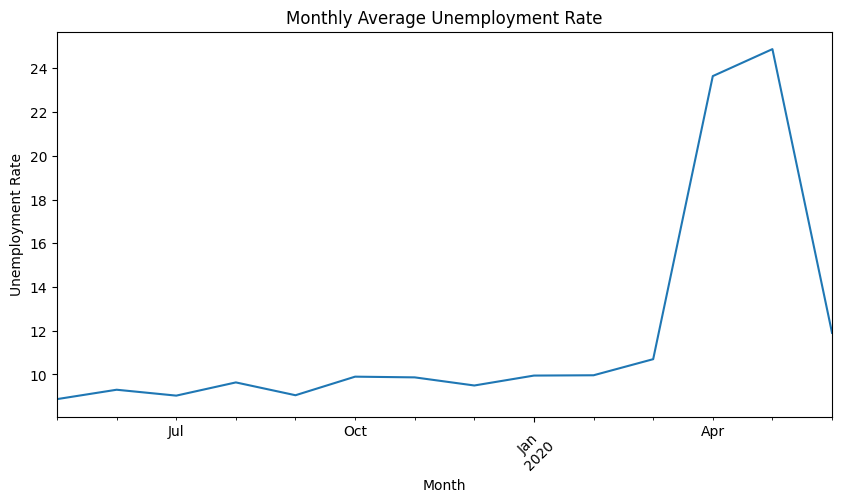

In [16]:
df['Month'] = df['Date'].dt.to_period('M')

monthly_avg = df.groupby('Month')['Estimated Unemployment Rate'].mean()

monthly_avg.plot(figsize=(10,5))
plt.title("Monthly Average Unemployment Rate")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate")
plt.xticks(rotation=45)
plt.show()

## State-wise analysis

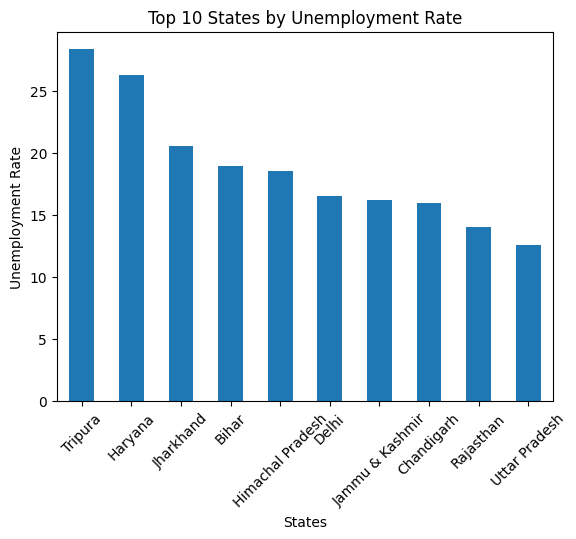

In [17]:
top_states = df.groupby('States')['Estimated Unemployment Rate'].mean() \
               .sort_values(ascending=False).head(10)
top_states.plot(kind='bar')
plt.title("Top 10 States by Unemployment Rate")
plt.ylabel("Unemployment Rate")
plt.xticks(rotation=45)
plt.show()

## Region-wise analysis

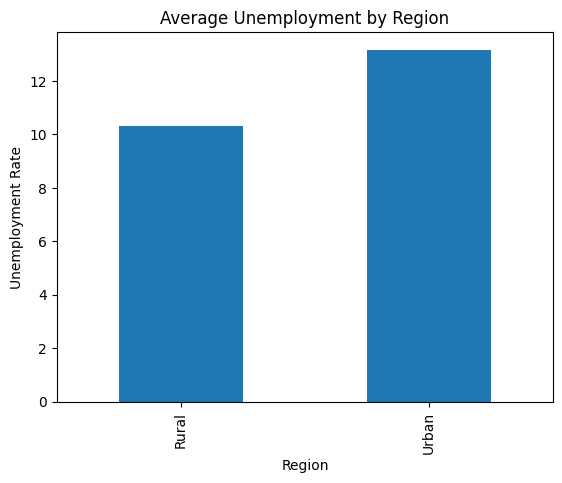

In [18]:
region_avg = df.groupby('Region')['Estimated Unemployment Rate'].mean()

region_avg.plot(kind='bar')
plt.title("Average Unemployment by Region")
plt.ylabel("Unemployment Rate")
plt.show()

## COVID Analysis (2020)

In [20]:
covid_monthly.sort_values().plot(kind='barh')
plt.title("COVID-19 Unemployment Rate by Month (2020)")
plt.xlabel("Unemployment Rate")
plt.show()

NameError: name 'covid_monthly' is not defined

## Top 5 v Bottom 5 States

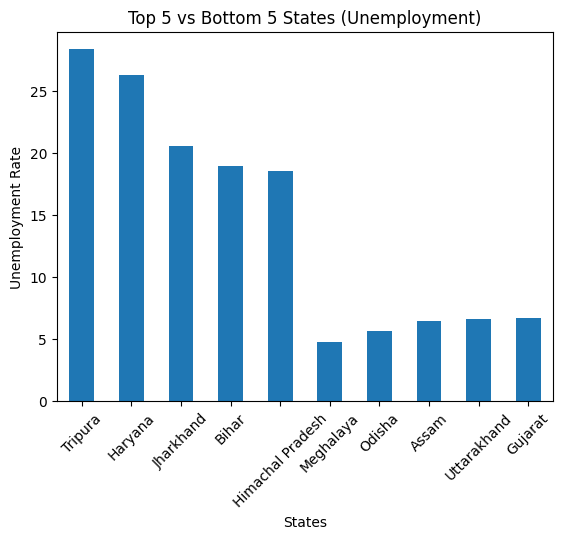

In [21]:
state_avg = df.groupby('States')['Estimated Unemployment Rate'].mean()

top5 = state_avg.sort_values(ascending=False).head(5)
bottom5 = state_avg.sort_values().head(5)

combined = pd.concat([top5, bottom5])

combined.plot(kind='bar')
plt.title("Top 5 vs Bottom 5 States (Unemployment)")
plt.ylabel("Unemployment Rate")
plt.xticks(rotation=45)
plt.show()

## Region-wise Unemployment Trend Over Time

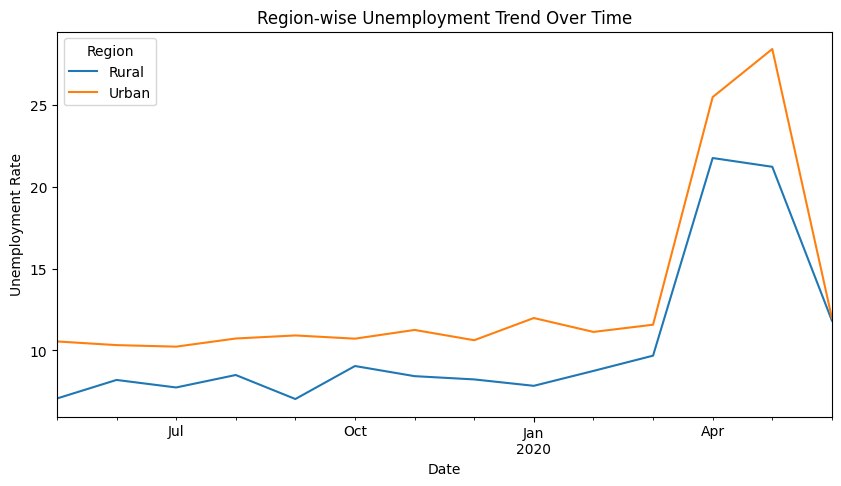

In [22]:
region_time = df.groupby(['Date', 'Region'])['Estimated Unemployment Rate'].mean().unstack()

region_time.plot(figsize=(10,5))
plt.title("Region-wise Unemployment Trend Over Time")
plt.ylabel("Unemployment Rate")

plt.show()